# analise do pipeline medalhao de dados de taxi em NY

este notebook conecta diretamente ao banco PostgreSQL e permite analisar os dados das camadas **Silver** e **Gold**.

In [1]:
import os
from pathlib import Path

import pandas as pd
import sqlalchemy
from sqlalchemy.engine import URL
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# configs visuais
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

def load_env_file():
    for env_path in (Path.cwd() / '.env', Path.cwd().parent / '.env'):
        if env_path.exists():
            for line in env_path.read_text().splitlines():
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    key, value = line.split('=', 1)
                    os.environ.setdefault(key.strip(), value.strip())
            break

load_env_file()

# conexao com o banco
db_url = URL.create(
    drivername='postgresql',
    username=os.environ.get('POSTGRES_USER', 'postgres'),
    password=os.environ.get('POSTGRES_PASSWORD', 'postgres'),
    host='localhost',
    port=5432,
    database=os.environ.get('NY_TAXI_DB_NAME', 'ny_taxi'),
)
engine = sqlalchemy.create_engine(db_url)
with engine.connect() as conn:
    pass
print('conexao com o banco estabelecida com sucesso')

conexao com o banco estabelecida com sucesso


---
## 1. camada silver

In [2]:
# total de linhas e separacao por validas e invalidas
df_qualidade = pd.read_sql("""
    SELECT
        CASE WHEN is_valid_trip THEN 'Validas' ELSE 'Invalidas' END AS status,
        COUNT(*) AS total
    FROM silver.trips
    GROUP BY is_valid_trip
""", engine)

df_qualidade['percentual'] = (df_qualidade['total'] * 100.0 / df_qualidade['total'].sum()).round(2)

print('qualidade dos dados (silver.trips)')
print(f"Total de registros: {df_qualidade['total'].sum():,}")
display(df_qualidade)

qualidade dos dados (silver.trips)
Total de registros: 20,505,841


,status,total,percentual
0,Invalidas,5834710,28.45
1,Validas,14671131,71.55


In [3]:
# principais motivos de invalidacao
df_motivos = pd.read_sql("""
    SELECT
        invalid_reason,
        COUNT(*) AS total
    FROM silver.trips
    WHERE is_valid_trip = false
    GROUP BY invalid_reason
    ORDER BY total DESC
    LIMIT 10
""", engine)

print('top 10 motivos de invalidacao')
display(df_motivos)

top 10 motivos de invalidacao


,invalid_reason,total
0,invalid_payment_type; invalid_passenger_count;...,4571375
1,invalid_payment_type,333344
2,invalid_payment_type; negative_total_amount,267053
3,invalid_ratecode_id,223108
4,invalid_dates_dropoff_before_pickup,187052
5,invalid_passenger_count,112417
6,negative_total_amount,85606
7,invalid_payment_type; negative_total_amount; i...,38145
8,anomaly_duration_gt_6h,6194
9,invalid_payment_type; invalid_passenger_count,3632


In [4]:
# tipos de pagamento
df_payment = pd.read_sql("SELECT * FROM silver.payment_types ORDER BY payment_type", engine)
print('Tipos de pagamento — silver.payment_types')
display(df_payment)

Tipos de pagamento — silver.payment_types


,payment_type,payment_description,is_valid_payment
0,1,Credit card,True
1,2,Cash,True
2,3,No charge,False
3,4,Dispute,False
4,5,Unknown,False
5,6,Voided trip,False


---
## 2. camada Gold — indicadores mensais

In [5]:
# Carregar view de indicadores mensais
df_gold = pd.read_sql("""
    SELECT *
    FROM gold.mv_monthly_indicators
    WHERE month_yyyymm >= '202501'
    ORDER BY month_yyyymm, vendor_id
""", engine)

print('gold.mv_monthly_indicators')
display(df_gold)

gold.mv_monthly_indicators


,month_yyyymm,vendor_id,total_rides,total_valid_amount,avg_ticket_amount,avg_distance
0,202501,1,753671,1.698298e+07,26.052192,3.198080
1,202501,2,2719868,6.011590e+07,27.553756,6.592583
2,202501,6,489,0.000000e+00,0.000000,8.795624
3,202501,7,1206,2.604990e+04,22.094911,1.962902
4,202502,1,754990,1.643147e+07,26.057333,2.996377
5,202502,2,2817802,5.603598e+07,27.457754,6.842582
6,202502,6,330,0.000000e+00,0.000000,8.587636
7,202502,7,4420,9.888730e+04,23.218432,2.221364
8,202503,1,834394,1.875831e+07,27.298947,3.424592
9,202503,2,3289020,6.873854e+07,28.621478,7.408895


---
## 3. camada gold — ana[lise da tabela fato fct_trips

In [6]:
# amostra da tabela 
df_fct = pd.read_sql("""
    SELECT *
    FROM gold.fct_trips
    WHERE is_valid_trip = true
    LIMIT 10
""", engine)

print('Amostra de gold.fct_trips (viagens validas)')
display(df_fct)

Amostra de gold.fct_trips (viagens validas)


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,rate_code_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,source_year_month,pickup_date,pickup_year_month,trip_duration_minutes,is_valid_trip,invalid_reason
0,2,2025-01-27 17:29:29,2025-01-27 17:41:05,1,2.85,1,N,261,232,1,...,1.0,22.85,2.5,0.00,202501,2025-01-27,202501,11.600000,True,None
1,2,2025-01-27 17:28:47,2025-01-27 18:03:58,1,10.39,1,N,138,239,1,...,1.0,78.72,2.5,1.75,202501,2025-01-27,202501,35.183333,True,None
2,2,2025-01-27 17:10:11,2025-01-27 17:20:23,1,1.10,1,N,236,140,1,...,1.0,20.64,2.5,0.00,202501,2025-01-27,202501,10.200000,True,None
3,2,2025-01-27 17:44:45,2025-01-27 18:02:54,1,6.18,1,N,138,256,1,...,1.0,44.71,0.0,1.75,202501,2025-01-27,202501,18.150000,True,None
4,2,2025-01-27 17:03:34,2025-01-27 17:08:50,1,0.43,1,N,161,162,2,...,1.0,13.75,2.5,0.00,202501,2025-01-27,202501,5.266667,True,None
5,2,2025-01-27 17:46:32,2025-01-27 17:56:06,1,0.86,1,N,230,186,1,...,1.0,19.86,2.5,0.00,202501,2025-01-27,202501,9.566667,True,None
6,2,2025-01-27 17:41:30,2025-01-27 18:51:38,1,19.29,1,N,132,211,1,...,1.0,122.34,2.5,1.75,202501,2025-01-27,202501,70.133333,True,None
7,2,2025-01-27 16:58:22,2025-01-27 17:11:07,1,1.71,1,N,186,113,1,...,1.0,21.35,2.5,0.00,202501,2025-01-27,202501,12.750000,True,None
8,2,2025-01-27 17:21:04,2025-01-27 17:33:00,1,2.00,1,N,170,237,1,...,1.0,22.00,2.5,0.00,202501,2025-01-27,202501,11.933333,True,None
9,2,2025-01-27 17:33:57,2025-01-27 17:45:57,1,2.33,1,N,237,74,2,...,1.0,19.30,2.5,0.00,202501,2025-01-27,202501,12.000000,True,None


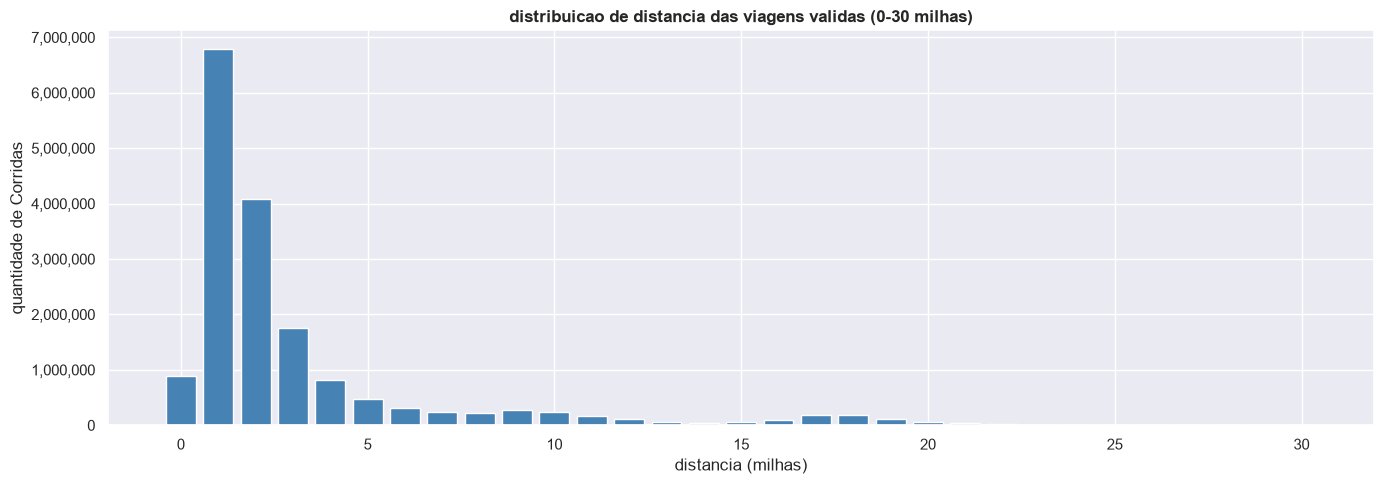

In [10]:
# distribuicao de distancia das viagens validas

#verificar se o grafico ficou correto depois

df_dist = pd.read_sql("""
    SELECT 
        ROUND(trip_distance::numeric, 0) AS distancia_milhas,
        COUNT(*) AS total
    FROM gold.fct_trips
    WHERE is_valid_trip = true
      AND trip_distance BETWEEN 0 AND 30
    GROUP BY distancia_milhas
    ORDER BY distancia_milhas
""", engine)

plt.figure(figsize=(14, 5))
plt.bar(df_dist['distancia_milhas'], df_dist['total'], color='steelblue', edgecolor='white')
plt.title('distribuicao de distancia das viagens validas (0-30 milhas)', fontweight='bold')
plt.xlabel('distancia (milhas)')
plt.ylabel('quantidade de Corridas')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

corridas e ticket medio por forma de pagamento


,payment_description,total_corridas,ticket_medio
0,Credit card,15609085,29.49
1,Cash,2353592,22.37
2,Dispute,544216,2.86
3,No charge,157887,7.80
4,Unknown,3,24.00


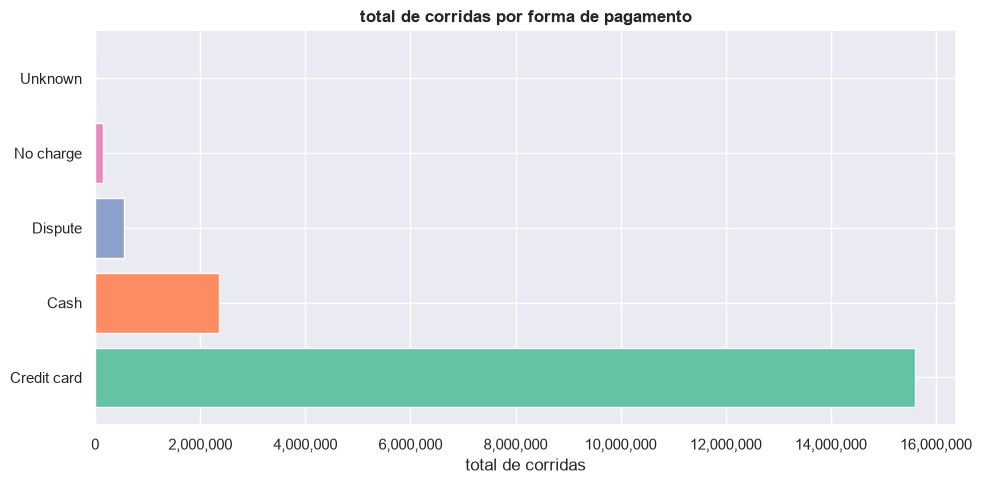

In [8]:
# forma de pagamento mais usada
df_pay = pd.read_sql("""
    SELECT 
        pt.payment_description,
        COUNT(t.payment_type) AS total_corridas,
        ROUND(AVG(t.total_amount)::numeric, 2) AS ticket_medio
    FROM gold.fct_trips t
    JOIN gold.dim_payment_types pt ON t.payment_type = pt.payment_type
    GROUP BY pt.payment_description
    ORDER BY total_corridas DESC
""", engine)

print('corridas e ticket medio por forma de pagamento')
display(df_pay)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_pay['payment_description'], df_pay['total_corridas'], color=sns.color_palette('Set2', len(df_pay)))
ax.set_title('total de corridas por forma de pagamento', fontweight='bold')
ax.set_xlabel('total de corridas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 4. Query Livre para bricnar

use a celula abaixo para rodar qualquer query que quiser

In [9]:
query = """
    SELECT *
    FROM gold.mv_monthly_indicators
    ORDER BY month_yyyymm
"""

df_custom = pd.read_sql(query, engine)
display(df_custom)

,month_yyyymm,vendor_id,total_rides,total_valid_amount,avg_ticket_amount,avg_distance
0,200712,2,1,2.275000e+01,22.750000,3.000000
1,200901,2,2,1.031200e+02,51.560000,7.620000
2,202412,2,21,5.891700e+02,28.055714,3.657619
3,202501,1,753671,1.698298e+07,26.052192,3.198080
4,202501,2,2719868,6.011590e+07,27.553756,6.592583
5,202501,6,489,0.000000e+00,0.000000,8.795624
6,202501,7,1206,2.604990e+04,22.094911,1.962902
7,202502,1,754990,1.643147e+07,26.057333,2.996377
8,202502,2,2817802,5.603598e+07,27.457754,6.842582
9,202502,6,330,0.000000e+00,0.000000,8.587636
